### MLP Model made using PyTorch
Relevant Statistics: Made via MLP with 5 layers 1024->output

| Category        | Accuracy  | Precision | Recall   | F1      |
|-----------------|-----------|-----------|----------|---------|
| any             | 0.837519  | 0.803354  | 0.798485 | 0.800912|
| epidural        | 0.621705  | 0.027375  | 0.739130 | 0.052795|
| intraparenchymal| 0.733643  | 0.478357  | 0.815000 | 0.602866|
| intraventricular| 0.684651  | 0.333089  | 0.811052 | 0.472237|
| subarachnoid    | 0.692713  | 0.360354  | 0.799020 | 0.496699|
| subdural        | 0.683411  | 0.341322  | 0.804795 | 0.479347|

AUC overall: 0.83

# Hemorrhage Detection MLP Model with Hyperparameter Optimization

This notebook implements a Multi-Layer Perceptron (MLP) for hemorrhage detection with automated hyperparameter optimization. The process follows these steps:

1. Setup and Data Preparation
2. Model Definition and Hyperparameter Optimization
3. Training the Best Model
4. Model Evaluation and Visualization
5. Save Model and Results

## 1. Setup and Data Preparation

In [1]:
# Import required libraries (PyTorch version)
import torch

print("PyTorch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA device")

# Check if CUDA is available
print(torch.cuda.is_available()) # True if CUDA is available

# Get the number of GPUs available
print(torch.cuda.device_count()) # Number of GPUs

# Get the name of the current GPU
print(torch.cuda.get_device_name(0)) # Name of GPU, e.g., 'GeForce GTX 950M'

PyTorch version: 2.7.1+cu128
CUDA version: 12.8
CUDA available: True
CUDA device name: NVIDIA GeForce RTX 5060 Laptop GPU
True
1
NVIDIA GeForce RTX 5060 Laptop GPU


In [2]:
# Import required libraries (CUDA version)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning libraries
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

# Import Optuna for hyperparameter optimization
import optuna
from optuna.trial import TrialState

c:\Users\bahra\anaconda3\envs\researchenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load the datasets into pandas DataFrames
df_hemo = pd.read_csv('../Rsna_ICH_Hemm.csv')
df_control = pd.read_csv('../Rsna_ICH_Control.csv')

# Combine the datasets
df = pd.concat([df_hemo, df_control], ignore_index=True)

# Convert the 'embedding' column from string to a list
df['embedding'] = df['embedding'].apply(eval)

# Define the target columns in the proper order
target_columns = ['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']

In [4]:
# Load the embeddings and target values
X = np.array(df['embedding'].tolist(), dtype=np.float32)
y = df[target_columns].values.astype(np.float32)

# Split the data with 80 percent for training and 20 percent for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [5]:
# Define an Early Stopping class

class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0

    def __call__(self, val_loss):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

### Calculate Class Weights for Imbalanced Data

## 2. Model Definition and Hyperparameter Optimization

In [24]:
# Create custom weights to handle class imbalance
# Calculate positive weights for each class
pos_weights = []
for i in range(len(target_columns)):
    num_pos = np.sum(y_train[:, i])
    num_neg = y_train.shape[0] - num_pos
    # Avoid division by zero
    weight = num_neg / (num_pos + 1e-6)
    pos_weights.append(weight)
pos_weights = torch.tensor(pos_weights, dtype=torch.float32)

# Move pos_weights to the same device as the model will be on
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weights = pos_weights.to(device)

# Use pos_weight in BCEWithLogitsLoss
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

In [25]:
# Define the dynamic MLP model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class HemorrhageMLP(nn.Module):
    def __init__(self, input_size, output_size, layer_sizes, dropout_rates):
        super(HemorrhageMLP, self).__init__()
        
        # Create a list to hold all layers
        layers = []
        prev_size = input_size
        
        # Add layers dynamically based on the provided sizes
        for i, size in enumerate(layer_sizes):
            layers.append(nn.Linear(prev_size, size))
            layers.append(nn.BatchNorm1d(size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rates[i]))
            prev_size = size
        
        # Add final output layer
        layers.append(nn.Linear(prev_size, output_size))
        
        # Create sequential model
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

def objective(trial):
    # Number of layers (between 3 and 7)
    n_layers = trial.suggest_int("n_layers", 3, 7)
    
    # Layer sizes (decreasing from input to output)
    layer_sizes = []
    prev_size = X_train_tensor.shape[1]  # Input size
    for i in range(n_layers):
        layer_sizes.append(trial.suggest_int(f"n_units_l{i}", 
                                           int(prev_size/2),  # At least half the previous size
                                           min(2048, prev_size*2)))  # At most double the previous size
        prev_size = layer_sizes[-1]
    
    # Dropout rates for each layer
    dropout_rates = [trial.suggest_float(f"dropout_l{i}", 0.1, 0.5) for i in range(n_layers)]
    
    # Learning rate
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    
    # Create model
    model = HemorrhageMLP(
        input_size=X_train_tensor.shape[1],
        output_size=len(target_columns),
        layer_sizes=layer_sizes,
        dropout_rates=dropout_rates
    ).to(device)
    
    # Optimizer
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Training loop
    best_val_loss = float('inf')
    patience = 5
    patience_counter = 0
    
    for epoch in range(50):  # Maximum 50 epochs
        model.train()
        train_loss = 0
        
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            output = model(xb)
            loss = criterion(output, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * xb.size(0)
            
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                output = model(xb)
                loss = criterion(output, yb)
                val_loss += loss.item() * xb.size(0)
        
        val_loss /= len(test_loader.dataset)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    
    return best_val_loss

In [26]:
# Create a study object and run optimization
study = optuna.create_study(direction="minimize")

# Run the optimization
print("Starting hyperparameter optimization...")
study.optimize(objective, n_trials=50)  # Try 50 different configurations

# Get the best parameters
best_trial = study.best_trial
print("Best trial:")
print("  Value: ", best_trial.value)
print("  Params: ")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

# Create the best model
best_n_layers = best_trial.params["n_layers"]
best_layer_sizes = [best_trial.params[f"n_units_l{i}"] for i in range(best_n_layers)]
best_dropout_rates = [best_trial.params[f"dropout_l{i}"] for i in range(best_n_layers)]

best_model = HemorrhageMLP(
    input_size=X_train_tensor.shape[1],
    output_size=len(target_columns),
    layer_sizes=best_layer_sizes,
    dropout_rates=best_dropout_rates
).to(device)

[I 2025-10-30 00:28:13,453] A new study created in memory with name: no-name-41270082-d1ef-4b10-84a5-805a3a50efdc


Starting hyperparameter optimization...


[I 2025-10-30 00:29:13,492] Trial 0 finished with value: 0.8207446019224418 and parameters: {'n_layers': 5, 'n_units_l0': 1865, 'n_units_l1': 2016, 'n_units_l2': 1454, 'n_units_l3': 811, 'n_units_l4': 976, 'dropout_l0': 0.33566968070274505, 'dropout_l1': 0.1256781949869925, 'dropout_l2': 0.4975378811485881, 'dropout_l3': 0.3702338342742645, 'dropout_l4': 0.3491047293755064, 'lr': 0.009845142638685555}. Best is trial 0 with value: 0.8207446019224418.
[W 2025-10-30 00:29:41,418] Trial 1 failed with parameters: {'n_layers': 7, 'n_units_l0': 1928, 'n_units_l1': 1210, 'n_units_l2': 1677, 'n_units_l3': 957, 'n_units_l4': 1190, 'n_units_l5': 1777, 'n_units_l6': 1044, 'dropout_l0': 0.47503854288634173, 'dropout_l1': 0.38913458225857844, 'dropout_l2': 0.39157175804247013, 'dropout_l3': 0.22502022328247318, 'dropout_l4': 0.3314013865615947, 'dropout_l5': 0.4221409467316096, 'dropout_l6': 0.42438170593656865, 'lr': 0.001946612563298268} because of the following error: KeyboardInterrupt().
Traceba

KeyboardInterrupt: 

## 3. Training the Best Model

In [21]:
# Train the best model

optimizer = optim.Adam(best_model.parameters(), lr=best_trial.params["lr"])
early_stopper = EarlyStopping(patience=5)

# Train the model using 50 epochs with early stopping
num_epochs = 50
for epoch in range(num_epochs):
    best_model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        output = best_model(xb)
        loss = criterion(output, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(best_model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)

    # Validation
    best_model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            output = best_model(xb)
            loss = criterion(output, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(test_loader.dataset)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    early_stopper(val_loss)
    if early_stopper.early_stop:
        print("Early stopping triggered.")
        break

Epoch 1: Train Loss=0.8628, Val Loss=0.8280
Epoch 2: Train Loss=0.8556, Val Loss=0.8249
Epoch 2: Train Loss=0.8556, Val Loss=0.8249
Epoch 3: Train Loss=0.8752, Val Loss=0.8258
Epoch 3: Train Loss=0.8752, Val Loss=0.8258
Epoch 4: Train Loss=0.8565, Val Loss=0.8312
Epoch 4: Train Loss=0.8565, Val Loss=0.8312
Epoch 5: Train Loss=0.8527, Val Loss=0.8214
Epoch 5: Train Loss=0.8527, Val Loss=0.8214
Epoch 6: Train Loss=0.8395, Val Loss=0.8289
Epoch 6: Train Loss=0.8395, Val Loss=0.8289
Epoch 7: Train Loss=0.8405, Val Loss=0.8267
Epoch 7: Train Loss=0.8405, Val Loss=0.8267
Epoch 8: Train Loss=0.8471, Val Loss=0.8343
Epoch 8: Train Loss=0.8471, Val Loss=0.8343
Epoch 9: Train Loss=0.8283, Val Loss=0.8456
Epoch 9: Train Loss=0.8283, Val Loss=0.8456
Epoch 10: Train Loss=0.8326, Val Loss=0.8463
Early stopping triggered.


In [22]:
from sklearn.metrics import accuracy_score

best_model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        output = best_model(xb)
        preds = (torch.sigmoid(output) > 0.5).cpu().numpy()
        y_true.append(yb.numpy())
        y_pred.append(preds)
y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)
print("Test accuracy (any class):", accuracy_score(y_true[:,0], y_pred[:,0]))

Test accuracy (any class): 0.8303875968992248


## 4. Model Evaluation and Visualization

           Category  Accuracy
0               any  0.830388
1          epidural  0.576434
2  intraparenchymal  0.741705
3  intraventricular  0.690233
4      subarachnoid  0.701705
5          subdural  0.697674


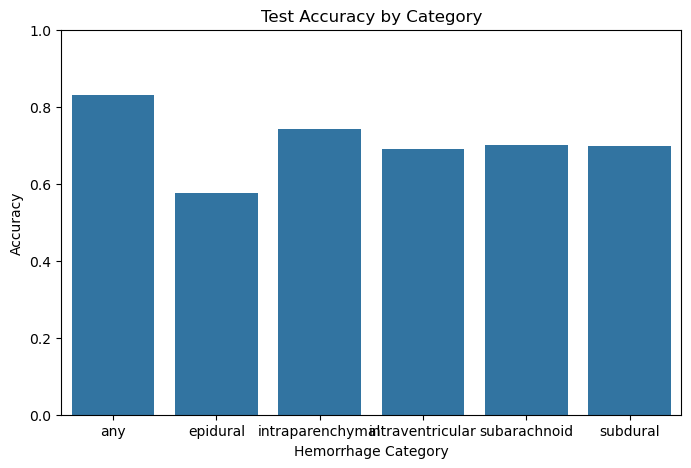

In [23]:
# Calculate accuracy for each category
accuracies = []
for i, col in enumerate(target_columns):
    acc = accuracy_score(y_true[:, i], y_pred[:, i])
    accuracies.append(acc)

# Prepare DataFrame for seaborn
acc_df = pd.DataFrame({
    'Category': target_columns,
    'Accuracy': accuracies
})

# Display statistics
print(acc_df)

# Plot using seaborn
plt.figure(figsize=(8, 5))
sns.barplot(x='Category', y='Accuracy', data=acc_df)
plt.ylim(0, 1)
plt.title('Test Accuracy by Category')
plt.ylabel('Accuracy')
plt.xlabel('Hemorrhage Category')
plt.show()

           Category  Accuracy  Precision    Recall        F1
0               any  0.831938   0.789866  0.803030  0.796394
1          epidural  0.528992   0.025757  0.869565  0.050031
2  intraparenchymal  0.735814   0.480539  0.802500  0.601124
3  intraventricular  0.687442   0.335541  0.812834  0.475000
4      subarachnoid  0.691783   0.359559  0.799020  0.495943
5          subdural  0.686202   0.343796  0.806507  0.482088


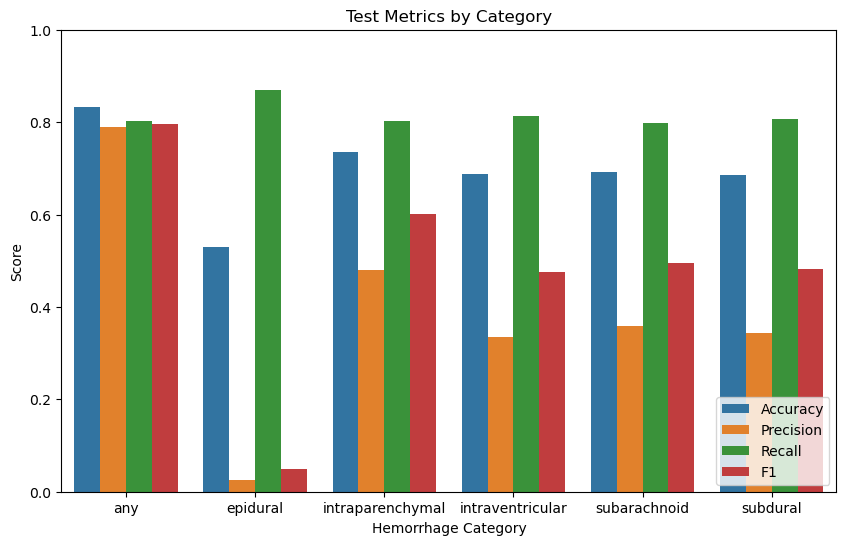

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics for each category
metrics = []
for i, col in enumerate(target_columns):
    acc = accuracy_score(y_true[:, i], y_pred[:, i])
    prec = precision_score(y_true[:, i], y_pred[:, i], zero_division=0)
    rec = recall_score(y_true[:, i], y_pred[:, i], zero_division=0)
    f1 = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)
    metrics.append({'Category': col, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})

# Prepare DataFrame for seaborn
import pandas as pd
metrics_df = pd.DataFrame(metrics)

# Display statistics
print(metrics_df)

# Plot using seaborn
plt.figure(figsize=(10, 6))
metrics_melted = metrics_df.melt(id_vars='Category', value_vars=['Accuracy', 'Precision', 'Recall', 'F1'],
                                 var_name='Metric', value_name='Score')
sns.barplot(x='Category', y='Score', hue='Metric', data=metrics_melted)
plt.ylim(0, 1)
plt.title('Test Metrics by Category')
plt.ylabel('Score')
plt.xlabel('Hemorrhage Category')
plt.legend(loc='lower right')
plt.show()

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
colors = sns.color_palette("tab10", len(target_columns))

for i, col in enumerate(target_columns):
    # Get true labels and predicted probabilities for each category
    fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
    auc = roc_auc_score(y_true[:, i], y_pred[:, i])
    sns.lineplot(x=fpr, y=tpr, color=colors[i], label=f"{col} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Hemorrhage')
plt.legend(loc='lower right')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.grid(True, ls=':', lw=0.5)  # Add grid lines
plt.tight_layout()
plt.show()

NameError: name 'y_score' is not defined

<Figure size 1000x700 with 0 Axes>

In [18]:
import numpy as np
import pandas as pd

# Calculate percentage of 1s and 0s for each category in the test set
category_stats = []
for i, col in enumerate(target_columns):
    total = len(y_true)
    ones = np.sum(y_true[:, i])
    zeros = total - ones
    percent_ones = ones / total * 100
    percent_zeros = zeros / total * 100
    category_stats.append({
        'Category': col,
        'Percent 1': percent_ones,
        'Percent 0': percent_zeros,
        'Count 1': int(ones),
        'Count 0': int(zeros),
        'Total': total
    })

stats_df = pd.DataFrame(category_stats)
print(stats_df)

           Category  Percent 1  Percent 0  Count 1  Count 0  Total
0               any  40.930233  59.069763     1320     1905   3225
1          epidural   1.426357  98.573647       46     3179   3225
2  intraparenchymal  24.806202  75.193802      800     2425   3225
3  intraventricular  17.395350  82.604652      561     2664   3225
4      subarachnoid  18.976744  81.023254      612     2613   3225
5          subdural  18.108528  81.891472      584     2641   3225


In [10]:
# Save the best model and hyperparameters
import json
import os

# Get the current directory path and create model_saves directory
current_dir = os.path.dirname(os.path.abspath('__file__'))
save_dir = os.path.join(current_dir, 'model_saves')

# Create a directory for the model if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Create full paths for saving
model_path = os.path.join(save_dir, 'best_hemorrhage_model.pth')
params_path = os.path.join(save_dir, 'model_hyperparameters.json')

# Save the model state
torch.save(best_model.state_dict(), model_path)

# Save hyperparameters
hyperparams = {
    'n_layers': best_n_layers,
    'layer_sizes': best_layer_sizes,
    'dropout_rates': best_dropout_rates,
    'learning_rate': best_trial.params["lr"],
    'input_size': X_train_tensor.shape[1],
    'output_size': len(target_columns)
}

with open(params_path, 'w') as f:
    json.dump(hyperparams, f, indent=4)

print(f"Model saved to: {model_path}")
print(f"Parameters saved to: {params_path}")

Model saved to: e:\CTResearch\ctfoundation\NewICHModels\model_saves\best_hemorrhage_model.pth
Parameters saved to: e:\CTResearch\ctfoundation\NewICHModels\model_saves\model_hyperparameters.json


## 5. Save Model and Results

# Best Model Architecture and Performance Summary

Below is a comprehensive summary of the best performing model configuration and its performance metrics.

In [11]:
# Display model architecture details
print("Best Model Architecture:")
print("-" * 50)
print(f"Number of layers: {best_n_layers}")
print("\nLayer sizes:")
for i, size in enumerate(best_layer_sizes):
    print(f"Layer {i+1}: {size} neurons (dropout: {best_dropout_rates[i]:.3f})")
print(f"\nLearning rate: {best_trial.params['lr']:.6f}")
print("-" * 50)

# Calculate and display performance metrics for each category
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

metrics_dict = {
    'Category': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'ROC AUC': [],
    'Positive Samples': [],
    'Negative Samples': []
}

for i, category in enumerate(target_columns):
    metrics_dict['Category'].append(category)
    metrics_dict['Accuracy'].append(accuracy_score(y_true[:, i], y_pred[:, i]))
    metrics_dict['Precision'].append(precision_score(y_true[:, i], y_pred[:, i], zero_division=0))
    metrics_dict['Recall'].append(recall_score(y_true[:, i], y_pred[:, i], zero_division=0))
    metrics_dict['F1 Score'].append(f1_score(y_true[:, i], y_pred[:, i], zero_division=0))
    metrics_dict['ROC AUC'].append(roc_auc_score(y_true[:, i], y_score[:, i]))
    metrics_dict['Positive Samples'].append(np.sum(y_true[:, i]))
    metrics_dict['Negative Samples'].append(len(y_true[:, i]) - np.sum(y_true[:, i]))

metrics_df = pd.DataFrame(metrics_dict)
print("\nDetailed Performance Metrics:")
print(metrics_df.round(4).to_string(index=False))

# Create visualization of the model architecture
plt.figure(figsize=(12, 6))
layer_sizes = [X_train_tensor.shape[1]] + best_layer_sizes + [len(target_columns)]
plt.plot(range(len(layer_sizes)), layer_sizes, 'bo-', linewidth=2, markersize=10)
plt.title('Model Architecture Visualization')
plt.xlabel('Layer')
plt.ylabel('Number of Neurons')
plt.grid(True)
for i, size in enumerate(layer_sizes):
    plt.text(i, size, str(size), ha='center', va='bottom')
plt.show()

# Plot correlation matrix of predictions
plt.figure(figsize=(10, 8))
correlation_matrix = np.corrcoef(y_score.T)
sns.heatmap(correlation_matrix, 
            xticklabels=target_columns,
            yticklabels=target_columns,
            annot=True,
            cmap='coolwarm',
            center=0,
            vmin=-1,
            vmax=1)
plt.title('Prediction Correlation Matrix')
plt.tight_layout()
plt.show()

Best Model Architecture:
--------------------------------------------------
Number of layers: 4

Layer sizes:
Layer 1: 900 neurons (dropout: 0.394)
Layer 2: 1515 neurons (dropout: 0.284)
Layer 3: 1436 neurons (dropout: 0.466)
Layer 4: 1655 neurons (dropout: 0.134)

Learning rate: 0.004380
--------------------------------------------------


NameError: name 'y_true' is not defined